In [4]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(".."))

from src.data import load_raw_dataset
from src.features import build_feature_pipeline
from src.models import train_lgb_time_series
from src.metrics import (
    evaluate_predictions,
    find_optimal_threshold,
    plot_evaluation_curves,
    plot_confusion_matrix,
)

In [11]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [optuna]2m3/4 [optuna]]]
Note: you may need to restart the kernel to use updated packages.


In [5]:
# 1. Load sample dataset
df_raw = load_raw_dataset(data_dir="../data/raw", split="train", nrows=25000)

# 2. Build engineered features
df_fe = build_feature_pipeline(df_raw)

# 3. Train LightGBM model across time-series folds
drop_cols = ["TransactionID", "TransactionDT", "isFraud", "uid1", "uid2"]
models, oof_preds, mean_auc = train_lgb_time_series(df_fe, target_col="isFraud", drop_cols=drop_cols, n_splits=3)

Loading train_transaction.csv...
Loading train_identity.csv...
Performing left join on TransactionID...
Optimizing memory footprint...
Memory usage decreased to 44.23 MB (46.6% reduction)
Extracting time features...
Constructing Pseudo User-IDs (UIDs)...
Applying Frequency Encoding...
Computing Group Aggregations & Deviations...
Feature engineering complete. Total columns: 472
Starting Time-Series CV (3 Folds) on 467 features...


/opt/anaconda3/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 ROC-AUC: 0.85809


/opt/anaconda3/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 ROC-AUC: 0.86274


/opt/anaconda3/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 ROC-AUC: 0.88155

--- Mean Out-Of-Fold ROC-AUC: 0.86746 ---


In [6]:
# 1. Evaluate baseline predictions at default 0.5 threshold
metrics = evaluate_predictions(df_fe["isFraud"].values, oof_preds, threshold=0.5)
print("=== Baseline Out-Of-Fold Performance (Threshold = 0.5) ===")
for k, v in metrics.items():
    print(f"{k:20s}: {v}")

# 2. Find optimal probability threshold (maximizing F1-score)
best_thresh, best_f1 = find_optimal_threshold(df_fe["isFraud"].values, oof_preds, metric="f1")
print(f"\nOptimal Decision Threshold : {best_thresh:.4f}")
print(f"Maximized F1-Score         : {best_f1:.4f}")

=== Baseline Out-Of-Fold Performance (Threshold = 0.5) ===
ROC_AUC             : 0.8190795295193215
PR_AUC              : 0.4535632481577653
Precision           : 0.85
Recall              : 0.24548736462093862
F1_Score            : 0.38095238095238093
True_Negatives      : 18172
False_Positives     : 24
False_Negatives     : 418
True_Positives      : 136

Optimal Decision Threshold : 0.1355
Maximized F1-Score         : 0.5058


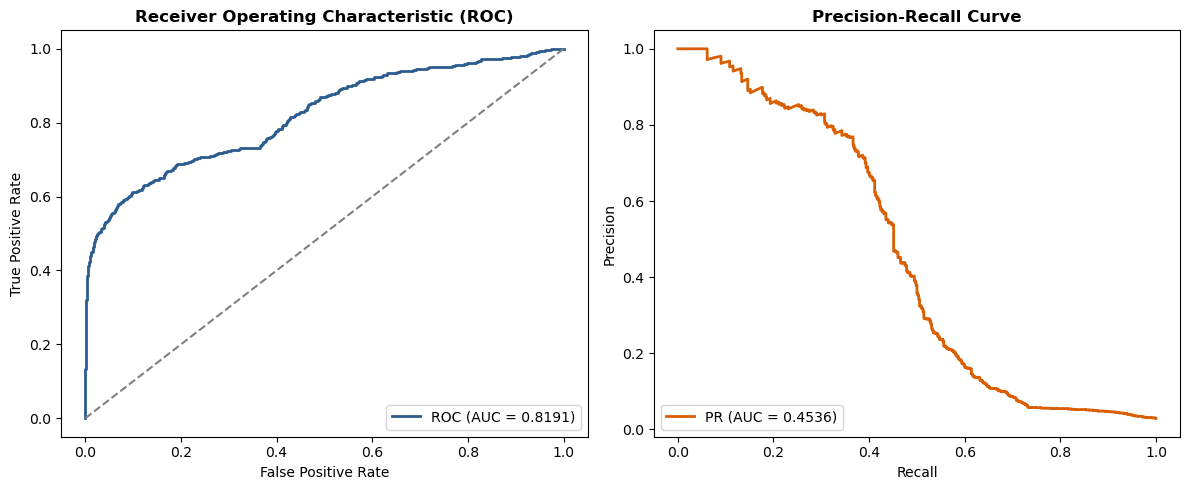

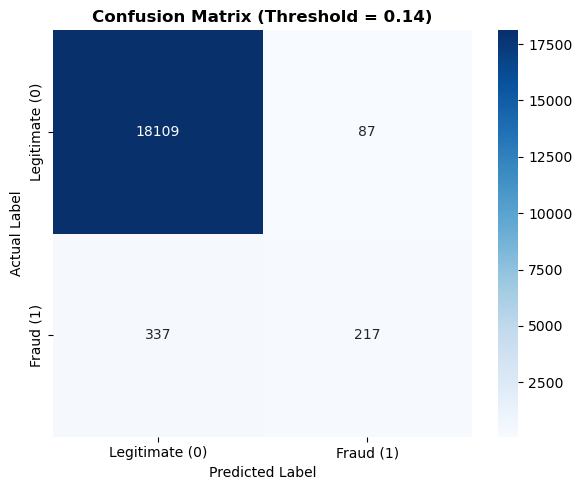

In [7]:
# 1. Plot ROC & Precision-Recall curves
plot_evaluation_curves(df_fe["isFraud"].values, oof_preds)

# 2. Display confusion matrix at optimal threshold
plot_confusion_matrix(df_fe["isFraud"].values, oof_preds, threshold=best_thresh)

/var/folders/tg/x63gz9yx2d7b1909v1ntkbw80000gn/T/ipykernel_17938/2036543584.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


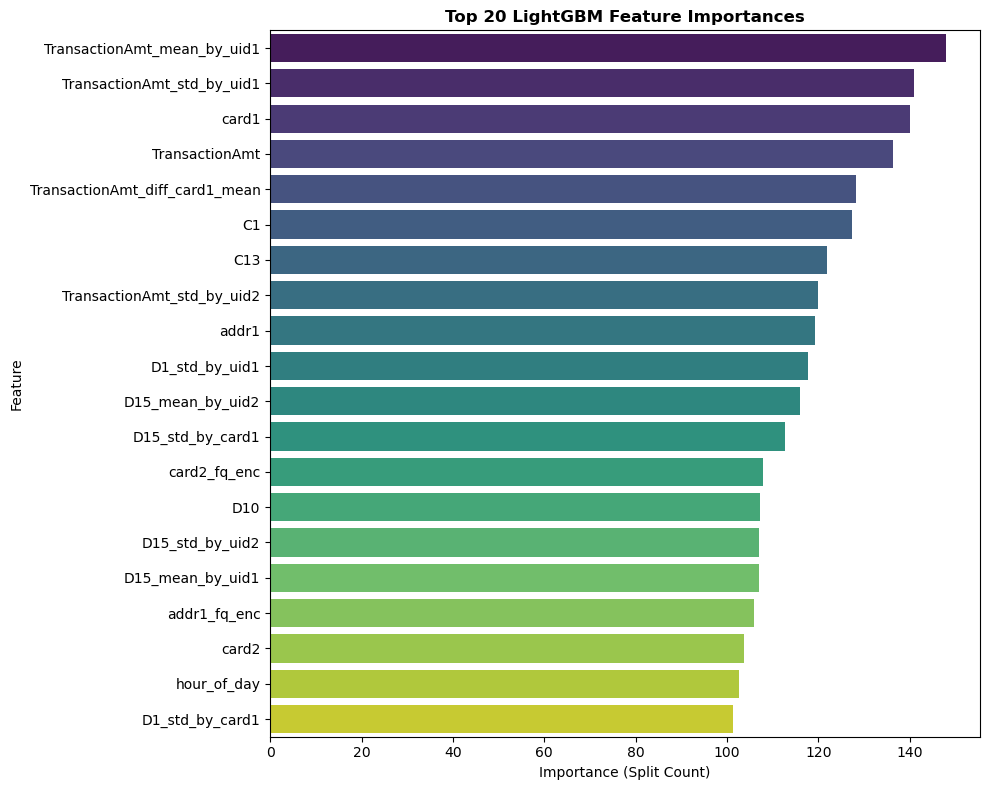

In [8]:
# Extract feature column names matching X
feature_names = [c for c in df_fe.columns if c not in drop_cols and not c.startswith("uid")]

# Compute mean feature importances across all CV fold models
importances = np.mean([model.feature_importances_ for model in models], axis=0)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

# Plot top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Top 20 LightGBM Feature Importances", fontweight="bold")
plt.xlabel("Importance (Split Count)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [9]:
pip install shap

  Using cached shap-0.52.0-cp312-abi3-macosx_10_13_x86_64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.52.0-cp312-abi3-macosx_10_13_x86_64.whl (496 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]1/2 [shap]
Note: you may need to restart the kernel to use updated packages.


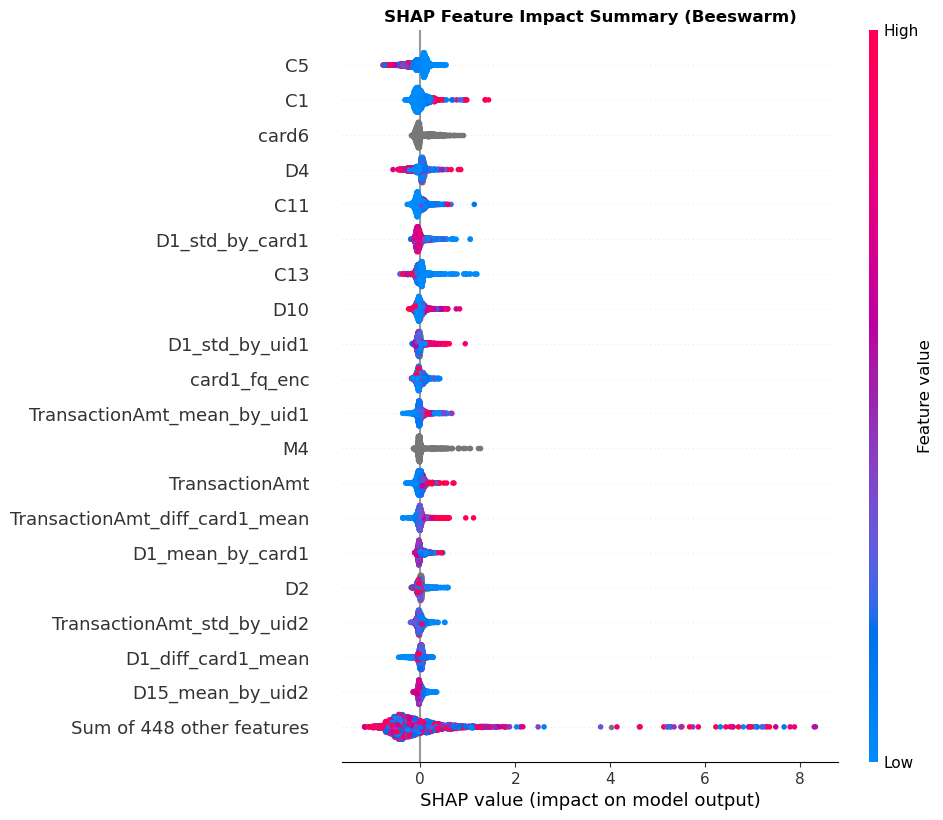

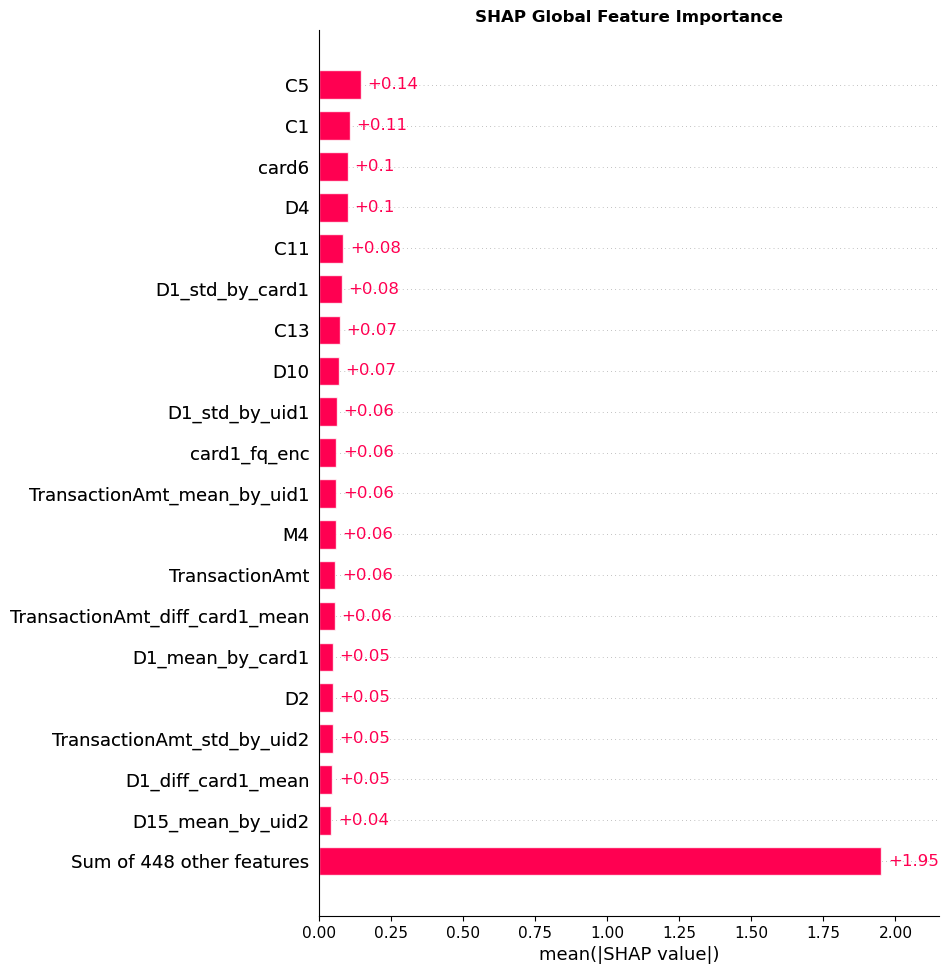

Explaining Transaction at Index 0
Predicted Fraud Probability: 0.0000


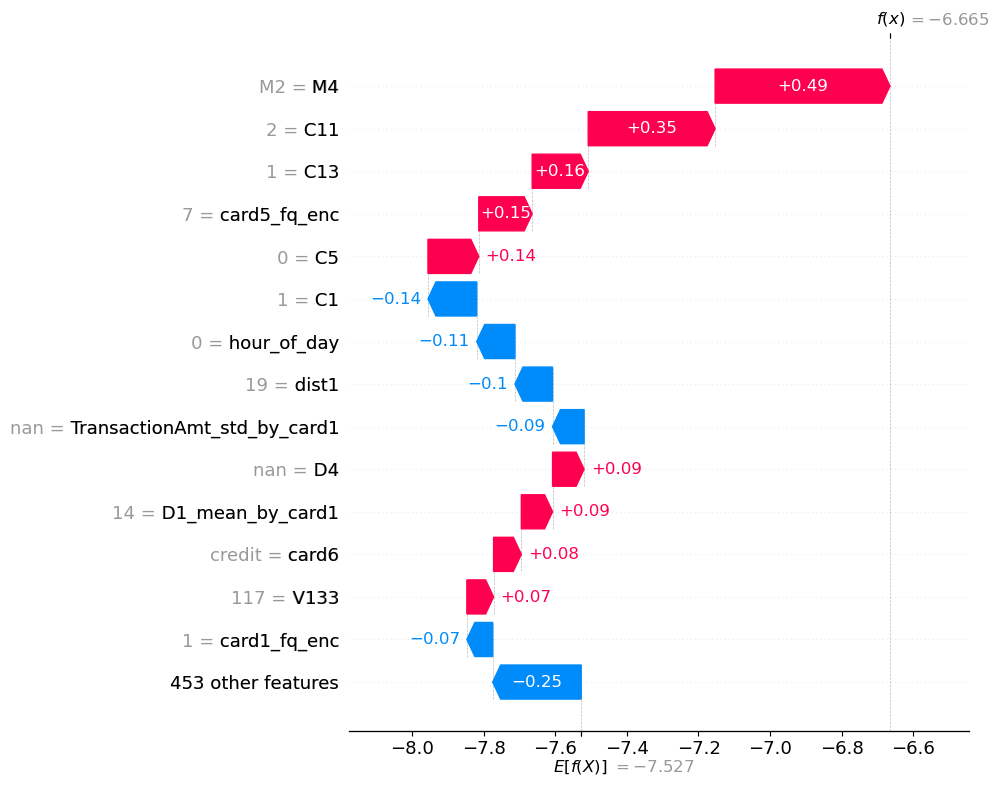

In [10]:
import shap

# 1. Prepare feature matrix X matching model input
feature_names = [c for c in df_fe.columns if c not in drop_cols and not c.startswith("uid")]
X = df_fe[feature_names].copy()

# Ensure categorical types are preserved
cat_cols = X.select_dtypes(include=["object", "string"]).columns
for c in cat_cols:
    X[c] = X[c].astype("category")

# 2. Use the first trained fold model for SHAP explanations
model = models[0]

# 3. Create a TreeExplainer and calculate SHAP values on a sample (e.g., 2,000 rows for speed)
sample_size = min(2000, len(X))
X_sample = X.iloc[:sample_size]

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)

# --- Global Explainability ---

# Plot 1: SHAP Summary Beeswarm Plot (Shows direction and magnitude of feature impacts)
plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Impact Summary (Beeswarm)", fontweight="bold")
shap.plots.beeswarm(shap_values, max_display=20)

# Plot 2: SHAP Global Bar Plot (Ranks features by average absolute SHAP impact)
plt.figure(figsize=(10, 6))
plt.title("SHAP Global Feature Importance", fontweight="bold")
shap.plots.bar(shap_values, max_display=20)

# --- Local Explainability (Individual Fraud Case) ---

# Find the highest predicted fraud probability index in the sample
sample_preds = oof_preds[:sample_size]
fraud_sample_idx = np.argmax(sample_preds)

print(f"Explaining Transaction at Index {fraud_sample_idx}")
print(f"Predicted Fraud Probability: {sample_preds[fraud_sample_idx]:.4f}")

# Plot 3: SHAP Waterfall Plot for a single high-risk transaction
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[fraud_sample_idx], max_display=15)